In [141]:
LABEL_MAP = {
    'cuprate': 'Cuprates',
    'iron-based': 'Iron-based',
    'heavy-fermion': 'Heavy fermion',
    'elemental': 'Elemental',
    'kagome': 'Kagome',
    'MgB2': r'MgB$_2$',
    'nickelate': 'Nickelates',
    'hydrogen': 'Hydrides',
    'ruthenate': 'Ruthenates'
}

### Fig.3a

Saved -> /home/vipandyc/data1/RevGPT/SC_analysis/output/figures_final_ver/fig3a_family_mechanism_heatmap.pdf


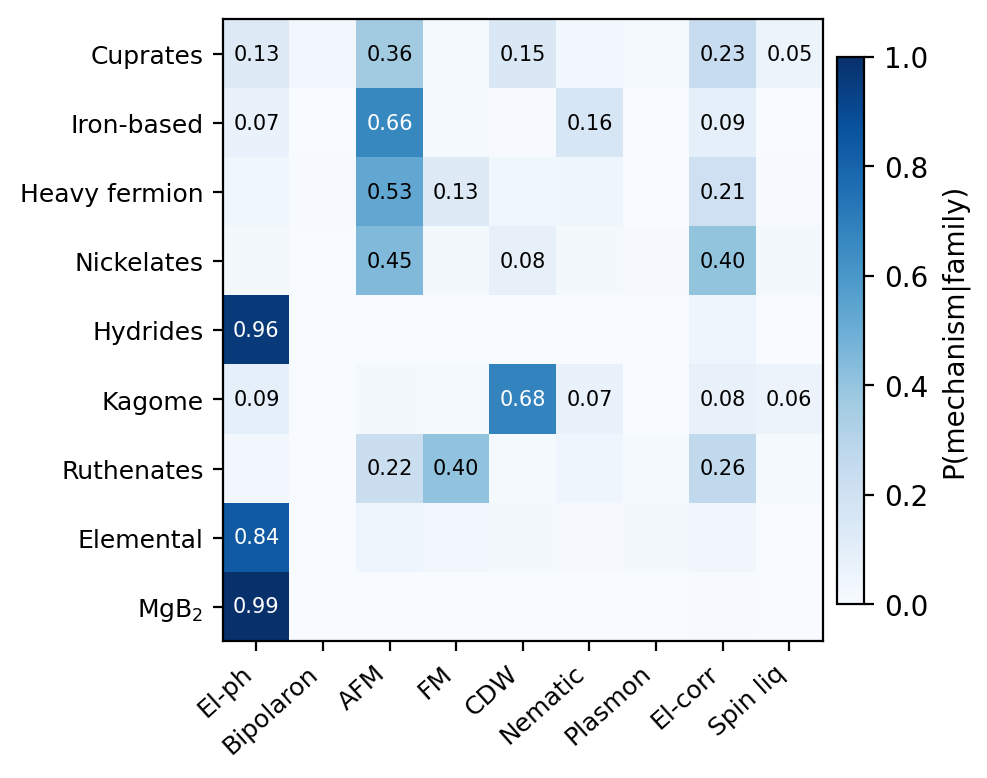

In [142]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
from fig_common import *

rows = load_rows()
mat  = build_fam_mech(rows, flat_weights(rows))
MLS  = [MECH_SHORT[m] for m in MECH_ORDER]
KEEP_FAMS = [
    'cuprate', 'iron-based', 'heavy-fermion',
    'elemental', 'kagome', 'MgB2',
    'nickelate', 'hydrogen', 'ruthenate'
]

mask = [f in KEEP_FAMS for f in DISP_FAMS]
mat_filt = mat[mask]
y_labels = [LABEL_MAP.get(f, f) for f in np.array(DISP_FAMS)[mask]]

fig, ax = plt.subplots(figsize=(5, 4))
draw_heatmap(ax, mat_filt, y_labels, MLS, "Blues", 0, 1,
             "Fig. 3.1 – Family × Mechanism\n(unweighted,  P(mech|family))",
             cbar_label="P(mechanism|family)", annot_frac=0.05)
fig.tight_layout()

out_dir = Path('/home/vipandyc/data1/RevGPT/SC_analysis/output/figures_final_ver')
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / f'fig3a_family_mechanism_heatmap.pdf'
fig.savefig(out_path, format='pdf', bbox_inches='tight')
print(f'Saved -> {out_path}')

### Fig.3b


Saved -> /home/vipandyc/data1/RevGPT/SC_analysis/output/figures_final_ver/fig3b_family_experimental_evidence_heatmap_exclude_trivial.pdf


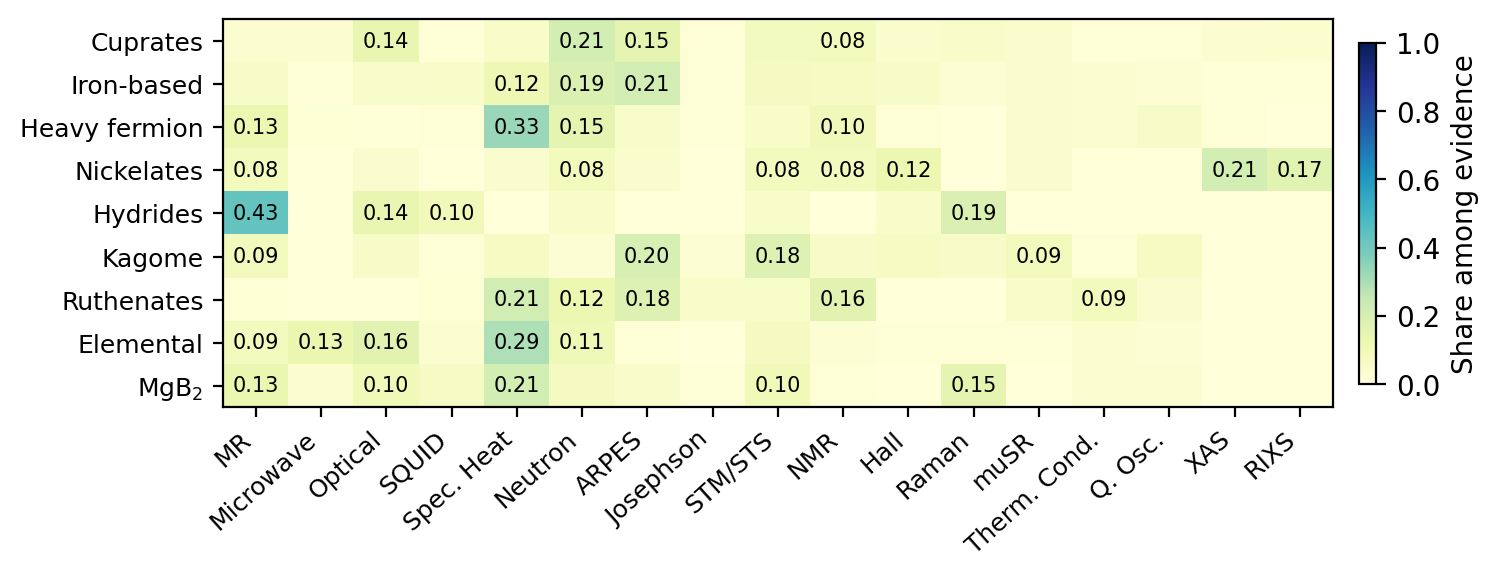

In [143]:
from fig_common import *
from pathlib import Path

rows = load_rows()

EXP_METHODS = [
    "Electrical Resistivity", "Magnetic Susceptibility", "Tc Measurement",
    "Magnetoresistance", "Microwave Spectroscopy", "Infrared / Optical Spectroscopy",
    "SQUID", "Specific Heat", "Neutron Scattering", "ARPES",
    "Josephson Junction", "STM/STS", "NMR", "Hall Effect", "Raman",
    "muSR", "Thermal Conductivity", "Quantum Oscillation", "XAS", "RIXS"
]
EXP_SHORT = {
    "Electrical Resistivity": "Resistivity",
    "Magnetic Susceptibility": "Mag. Susc.",
    "Tc Measurement": "Tc",
    "Magnetoresistance": "MR",
    "Microwave Spectroscopy": "Microwave",
    "Infrared / Optical Spectroscopy": "Optical",
    "SQUID": "SQUID",
    "Specific Heat": "Spec. Heat",
    "Neutron Scattering": "Neutron",
    "ARPES": "ARPES",
    "Josephson Junction": "Josephson",
    "STM/STS": "STM/STS",
    "NMR": "NMR",
    "Hall Effect": "Hall",
    "Raman": "Raman",
    "muSR": "muSR",
    "Thermal Conductivity": "Therm. Cond.",
    "Quantum Oscillation": "Q. Osc.",
    "XAS": "XAS",
    "RIXS": "RIXS",
}
KEEP_FAMS = [
    'cuprate', 'iron-based', 'heavy-fermion',
    'elemental', 'kagome', 'MgB2',
    'nickelate', 'hydrogen', 'ruthenate'
]

# Optional switch: exclude trivial experimental evidence and renormalize on kept methods
EXCLUDE_TRIVIAL_EXP = True
TRIVIAL_EXP_METHODS = {"Electrical Resistivity", "Magnetic Susceptibility", "Tc Measurement"}
RENORMALIZE_ON_KEPT = True


def parse_exp(val):
    text = str(val).strip()
    if text in ("none", "", "nan", "None"):
        return []
    return [m.strip() for m in text.split(" | ") if m.strip()]


active_methods = [
    m for m in EXP_METHODS
    if (not EXCLUDE_TRIVIAL_EXP) or (m not in TRIVIAL_EXP_METHODS)
]

families = [f for f in DISP_FAMS if f in KEEP_FAMS]
f2i = {f: i for i, f in enumerate(families)}
e2i = {e: i for i, e in enumerate(active_methods)}

mat = np.zeros((len(families), len(active_methods)), dtype=float)
fam_tot = np.zeros(len(families), dtype=float)

for r in rows:
    fam = r.get("family")
    if fam not in f2i:
        continue
    fi = f2i[fam]
    fam_tot[fi] += 1.0

    seen = set()
    for ev in parse_exp(r.get("evidence_experiment", "none")):
        if ev in e2i:
            seen.add(ev)
    for ev in seen:
        mat[fi, e2i[ev]] += 1.0

if EXCLUDE_TRIVIAL_EXP and RENORMALIZE_ON_KEPT:
    # Normalize each family row over kept evidence methods only.
    row_sum = mat.sum(axis=1, keepdims=True)
    row_sum[row_sum == 0] = 1.0
    mat = mat / row_sum
    cbar_label = "Share among evidence"
    subtitle = "(excluded Resistivity / Mag. Susc. / Tc; row-renormalized)"
else:
    fam_tot[fam_tot == 0] = 1.0
    mat = mat / fam_tot[:, None]
    cbar_label = "Fraction of papers in family"
    subtitle = "(all evidence methods)"

y_labels = [LABEL_MAP.get(f, f) for f in families]
x_labels = [EXP_SHORT.get(e, e) for e in active_methods]

fig, ax = plt.subplots(figsize=(8, 3))
draw_heatmap(
    ax,
    mat,
    y_labels,
    x_labels,
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    title=f"Fig. 3.2 – Family × Experimental Evidence\n{subtitle}",
    cbar_label=cbar_label,
    annot_frac=0.08,
)
fig.tight_layout()

out_dir = Path('/home/vipandyc/data1/RevGPT/SC_analysis/output/figures_final_ver')
out_dir.mkdir(parents=True, exist_ok=True)
suffix = '_exclude_trivial' if EXCLUDE_TRIVIAL_EXP else ''
out_path = out_dir / f'fig3b_family_experimental_evidence_heatmap{suffix}.pdf'
fig.savefig(out_path, format='pdf', bbox_inches='tight')
print(f'Saved -> {out_path}')
plt.show()



### Fig.3c


Saved -> /home/vipandyc/data1/RevGPT/SC_analysis/output/figures_final_ver/fig3c_mechanism_experimental_evidence_heatmap_exclude_trivial.pdf


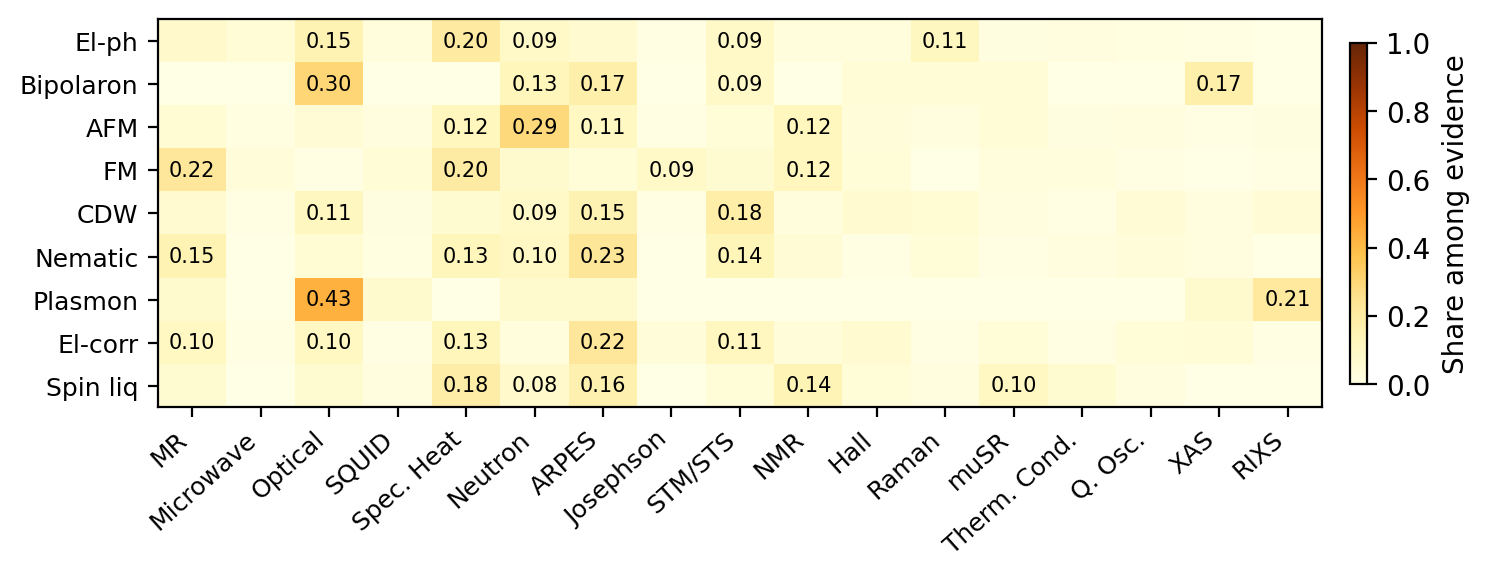

In [144]:
from fig_common import *
from pathlib import Path

rows = load_rows()

EXP_METHODS = [
    "Electrical Resistivity", "Magnetic Susceptibility", "Tc Measurement",
    "Magnetoresistance", "Microwave Spectroscopy", "Infrared / Optical Spectroscopy",
    "SQUID", "Specific Heat", "Neutron Scattering", "ARPES",
    "Josephson Junction", "STM/STS", "NMR", "Hall Effect", "Raman",
    "muSR", "Thermal Conductivity", "Quantum Oscillation", "XAS", "RIXS"
]
EXP_SHORT = {
    "Electrical Resistivity": "Resistivity",
    "Magnetic Susceptibility": "Mag. Susc.",
    "Tc Measurement": "Tc",
    "Magnetoresistance": "MR",
    "Microwave Spectroscopy": "Microwave",
    "Infrared / Optical Spectroscopy": "Optical",
    "SQUID": "SQUID",
    "Specific Heat": "Spec. Heat",
    "Neutron Scattering": "Neutron",
    "ARPES": "ARPES",
    "Josephson Junction": "Josephson",
    "STM/STS": "STM/STS",
    "NMR": "NMR",
    "Hall Effect": "Hall",
    "Raman": "Raman",
    "muSR": "muSR",
    "Thermal Conductivity": "Therm. Cond.",
    "Quantum Oscillation": "Q. Osc.",
    "XAS": "XAS",
    "RIXS": "RIXS",
}

# Optional switch: exclude trivial experimental evidence and renormalize on kept methods
EXCLUDE_TRIVIAL_EXP = True
TRIVIAL_EXP_METHODS = {"Electrical Resistivity", "Magnetic Susceptibility", "Tc Measurement"}
RENORMALIZE_ON_KEPT = True


def parse_exp(val):
    text = str(val).strip()
    if text in ("none", "", "nan", "None"):
        return []
    return [m.strip() for m in text.split(" | ") if m.strip()]


active_methods = [
    m for m in EXP_METHODS
    if (not EXCLUDE_TRIVIAL_EXP) or (m not in TRIVIAL_EXP_METHODS)
]

mechanisms = list(MECH_ORDER)
m2i = {m: i for i, m in enumerate(mechanisms)}
e2i = {e: i for i, e in enumerate(active_methods)}

mat = np.zeros((len(mechanisms), len(active_methods)), dtype=float)
mech_tot = np.zeros(len(mechanisms), dtype=float)

for r in rows:
    mech = r.get("mechanism")
    if mech not in m2i:
        continue
    mi = m2i[mech]
    mech_tot[mi] += 1.0

    seen = set()
    for ev in parse_exp(r.get("evidence_experiment", "none")):
        if ev in e2i:
            seen.add(ev)
    for ev in seen:
        mat[mi, e2i[ev]] += 1.0

if EXCLUDE_TRIVIAL_EXP and RENORMALIZE_ON_KEPT:
    # Normalize each mechanism row over kept evidence methods only.
    row_sum = mat.sum(axis=1, keepdims=True)
    row_sum[row_sum == 0] = 1.0
    mat = mat / row_sum
    cbar_label = "Share among evidence"
    subtitle = "(excluded Resistivity / Mag. Susc. / Tc; row-renormalized)"
else:
    mech_tot[mech_tot == 0] = 1.0
    mat = mat / mech_tot[:, None]
    cbar_label = "Fraction of papers in mechanism"
    subtitle = "(all evidence methods)"

y_labels = [MECH_SHORT.get(m, m) for m in mechanisms]
x_labels = [EXP_SHORT.get(e, e) for e in active_methods]

fig, ax = plt.subplots(figsize=(8, 3))
draw_heatmap(
    ax,
    mat,
    y_labels,
    x_labels,
    cmap="YlOrBr",
    vmin=0,
    vmax=1,
    title=f"Fig. 3.3 – Mechanism × Experimental Evidence\n{subtitle}",
    cbar_label=cbar_label,
    annot_frac=0.08,
)
fig.tight_layout()

out_dir = Path('/home/vipandyc/data1/RevGPT/SC_analysis/output/figures_final_ver')
out_dir.mkdir(parents=True, exist_ok=True)
suffix = '_exclude_trivial' if EXCLUDE_TRIVIAL_EXP else ''
out_path = out_dir / f'fig3c_mechanism_experimental_evidence_heatmap{suffix}.pdf'
fig.savefig(out_path, format='pdf', bbox_inches='tight')
print(f'Saved -> {out_path}')
plt.show()

### Fig.3d-g Ablation Distributions

Here the violin width are rescaled from $x$ to $\ln(1+x)$

Saved -> /home/vipandyc/data1/RevGPT/SC_analysis/output/figures_final_ver/fig3d_ablation1_smoothed_distribution.pdf


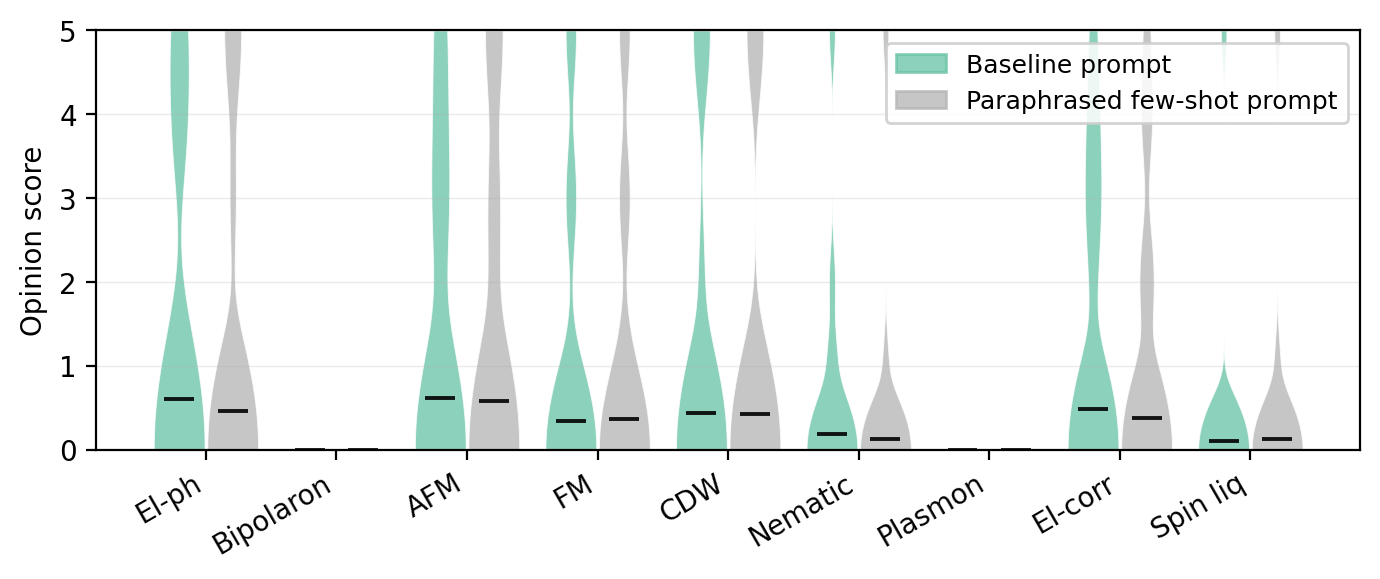

Saved -> /home/vipandyc/data1/RevGPT/SC_analysis/output/figures_final_ver/fig3e_ablation1_5_smoothed_distribution.pdf


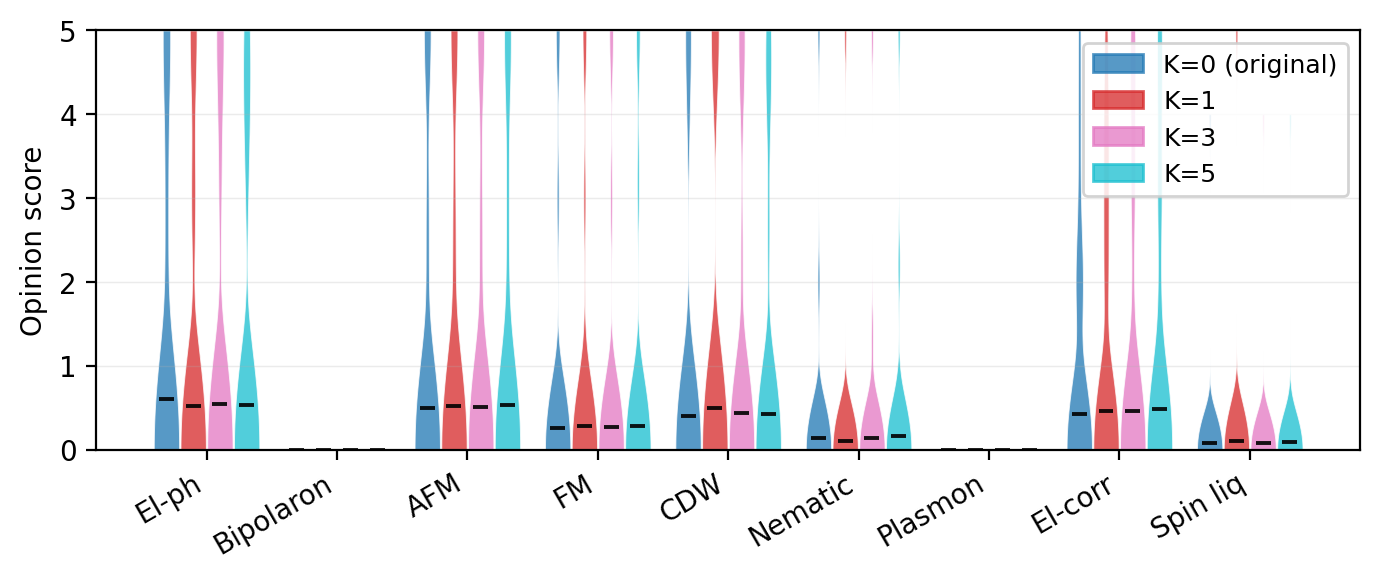

Saved -> /home/vipandyc/data1/RevGPT/SC_analysis/output/figures_final_ver/fig3f_ablation4_smoothed_distribution.pdf


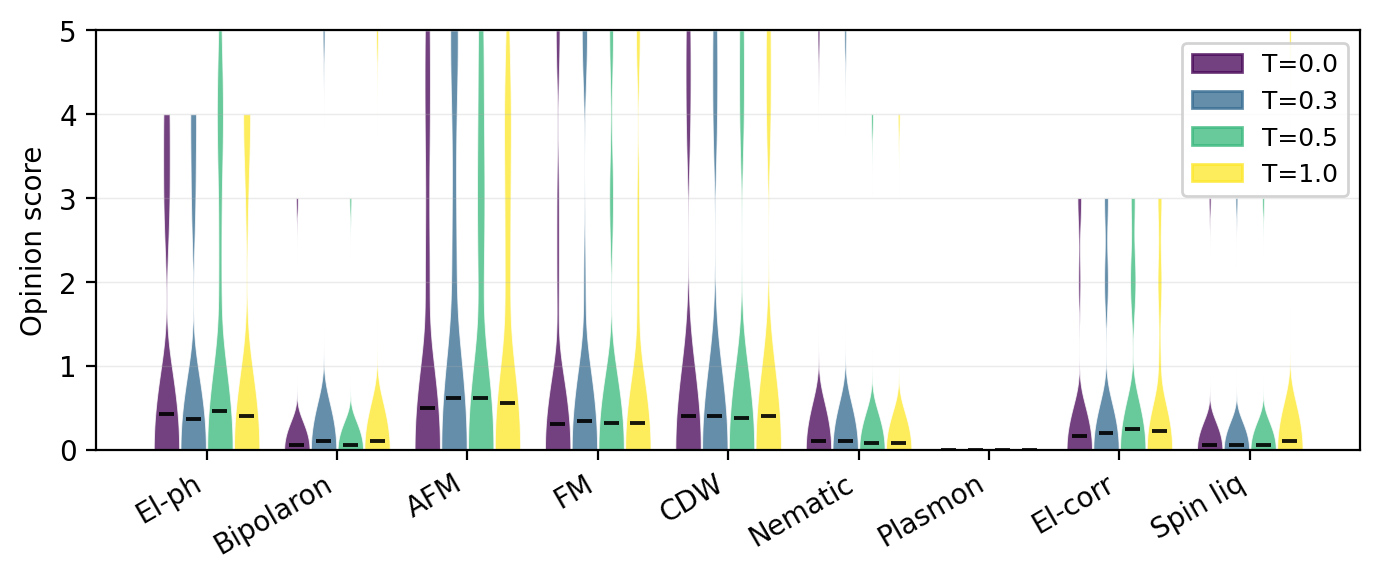

Saved -> /home/vipandyc/data1/RevGPT/SC_analysis/output/figures_final_ver/fig3g_ablation6_smoothed_distribution.pdf


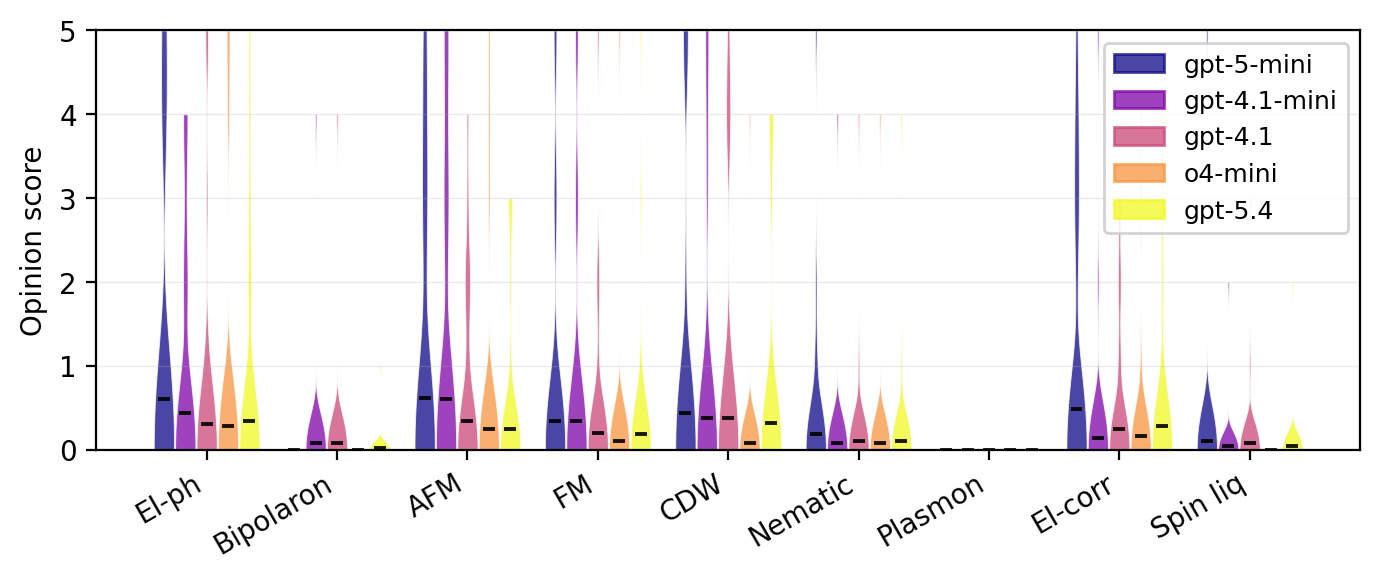

In [145]:
from fig_common import *
from pathlib import Path
from collections import OrderedDict
import csv
import json
import re
import matplotlib.patches as mpatches

ABL_ROOT = Path('/home/vipandyc/data1/RevGPT/ablation')
OUT_DIR = Path('/home/vipandyc/data1/RevGPT/SC_analysis/output/figures_final_ver')
OUT_DIR.mkdir(parents=True, exist_ok=True)

INCLUDE_ZERO_SCORES = True  # set False to hide zeros before plotting distributions
DENSITY_SCALE_MODE = 'log'  # 'identity' | 'log'
DENSITY_LOG_ALPHA = 100.0     # larger => more tail visibility in violin width
EXCLUDE_TESTS = ['T=0.7', 'o3', 'gpt4.1', 'gpt-5']

MECH_KEYS = list(MECH_ORDER)
MECH_LABELS = [MECH_SHORT.get(m, m) for m in MECH_KEYS]


def score_to_plot(v):
    # Keep score axis in original units.
    return float(np.clip(v, 0.0, 5.0))


def parse_gpt_output(raw):
    if not isinstance(raw, str) or not raw.strip():
        return {}
    text = re.sub(r"```[a-zA-Z]*\n?", "", raw).strip().rstrip("`")
    try:
        return json.loads(text)
    except Exception:
        m = re.search(r"\{.*\}", text, re.DOTALL)
        if m:
            try:
                return json.loads(m.group())
            except Exception:
                return {}
    return {}


def mechanism_scores_from_gpt_csv(path):
    out = {k: [] for k in MECH_KEYS}
    with open(path, newline='', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        for row in reader:
            obj = parse_gpt_output(row.get('GPT_output', ''))
            for k in MECH_KEYS:
                try:
                    v = float(obj.get(k, 0.0) or 0.0)
                except Exception:
                    v = 0.0
                out[k].append(v)

    if not INCLUDE_ZERO_SCORES:
        out = {k: [v for v in vals if v > 0] for k, vals in out.items()}
    return out


def mechanism_scores_from_aggregated_csv(path):
    out = {k: [] for k in MECH_KEYS}
    with open(path, newline='', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        for row in reader:
            for k in MECH_KEYS:
                try:
                    v = float(row.get(k, 0.0) or 0.0)
                except Exception:
                    v = 0.0
                out[k].append(v)

    if not INCLUDE_ZERO_SCORES:
        out = {k: [v for v in vals if v > 0] for k, vals in out.items()}
    return out


def plot_grouped_vertical_distributions(condition_to_mech_scores, title, out_name, cmap_name='tab10'):
    conditions = [cond for cond in condition_to_mech_scores.keys() if cond not in EXCLUDE_TESTS]
    n_cond = len(conditions)
    x = np.arange(len(MECH_KEYS), dtype=float)

    fig, ax = plt.subplots(figsize=(7, 3))
    cmap = plt.get_cmap(cmap_name)
    colors = [cmap(i / max(n_cond - 1, 1)) for i in range(n_cond)]

    group_width = 0.82
    violin_width = group_width / max(n_cond, 1)

    legend_handles = []

    for j, cond in enumerate(conditions):
        offset = (j - (n_cond - 1) / 2.0) * violin_width
        positions = x + offset

        data = []
        means_plot = []
        for m in MECH_KEYS:
            vals = condition_to_mech_scores[cond].get(m, [])
            if len(vals) == 0:
                vals = [0.0]
            data.append([score_to_plot(v) for v in vals])
            means_plot.append(float(np.mean(vals)) if len(vals) > 0 else 0.0)

        vp = ax.violinplot(
            data,
            positions=positions,
            widths=violin_width * 0.95,
            showmeans=False,
            showmedians=False,
            showextrema=False,
        )

        for body, xp in zip(vp['bodies'], positions):
            body.set_facecolor(colors[j])
            body.set_edgecolor('white')
            body.set_linewidth(0.35)
            body.set_alpha(0.75)

            if DENSITY_SCALE_MODE == 'log':
                # Log-scale the density axis (violin width) to reveal tails.
                path = body.get_paths()[0]
                verts = path.vertices
                dx = verts[:, 0] - xp
                max_abs = float(np.max(np.abs(dx))) if len(dx) else 0.0
                if max_abs > 0:
                    scaled = np.log1p(DENSITY_LOG_ALPHA * np.abs(dx))
                    scaled /= np.log1p(DENSITY_LOG_ALPHA * max_abs)
                    verts[:, 0] = xp + np.sign(dx) * scaled * max_abs

        # small mean bars for quick reference
        bar_half = violin_width * 0.28
        for xp, mu in zip(positions, means_plot):
            ax.hlines(mu, xp - bar_half, xp + bar_half,
                      colors='black', linewidth=1.4, alpha=0.9, zorder=4)

        n_refs = [len(condition_to_mech_scores[cond].get(m, [])) for m in MECH_KEYS]
        # label = f"{cond} (n~{max(n_refs) if n_refs else 0})"
        label = f"{cond}"
        legend_handles.append(mpatches.Patch(color=colors[j], alpha=0.75, label=label))

    # ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(MECH_LABELS, rotation=30, ha='right')
    # ax.set_xlabel('SC mechanism')
    ax.set_ylabel('Opinion score')
    ax.set_ylim(0, 5)
    ax.set_yticks([0, 1, 2, 3, 4, 5])
    ax.grid(axis='y', alpha=0.25, linewidth=0.5)
    ax.legend(handles=legend_handles, fontsize=9, framealpha=0.85, loc='upper right')
    note = f"density-scale={DENSITY_SCALE_MODE} (alpha={DENSITY_LOG_ALPHA})"
    #zero_note = 'including zeros' if INCLUDE_ZERO_SCORES else 'non-zero only'
    #ax.text(0.01, 0.98, f"{zero_note}; {note}", transform=ax.transAxes,
    #        va='top', ha='left', fontsize=7.5, alpha=0.8)

    fig.tight_layout()
    out_path = OUT_DIR / out_name
    fig.savefig(out_path, format='pdf', bbox_inches='tight')
    print(f'Saved -> {out_path}')
    plt.show()


# --- Collect ablation datasets ---
ab1 = OrderedDict([
    ('Baseline prompt', mechanism_scores_from_gpt_csv(ABL_ROOT / 'ablation1_paraphrase_examples/results/baseline_scores.csv')),
    ('Paraphrased few-shot prompt', mechanism_scores_from_gpt_csv(ABL_ROOT / 'ablation1_paraphrase_examples/results/paraphrased_scores.csv')),
])

ab15 = OrderedDict([
    ('K=0 (original)', mechanism_scores_from_aggregated_csv(ABL_ROOT / 'ablation1_5_paraphrase_abstracts/results/aggregated_k0_original.csv')),
    ('K=1', mechanism_scores_from_aggregated_csv(ABL_ROOT / 'ablation1_5_paraphrase_abstracts/results/aggregated_k1.csv')),
    ('K=3', mechanism_scores_from_aggregated_csv(ABL_ROOT / 'ablation1_5_paraphrase_abstracts/results/aggregated_k3.csv')),
    ('K=5', mechanism_scores_from_aggregated_csv(ABL_ROOT / 'ablation1_5_paraphrase_abstracts/results/aggregated_k5.csv')),
])

ab4_files = [
    ('T=0.0', 'scores_T0p0.csv'),
    ('T=0.3', 'scores_T0p3.csv'),
    ('T=0.5', 'scores_T0p5.csv'),
    ('T=0.7', 'scores_T0p7.csv'),
    ('T=1.0', 'scores_T1p0.csv'),
]
ab4 = OrderedDict()
for label, fname in ab4_files:
    ab4[label] = mechanism_scores_from_gpt_csv(ABL_ROOT / 'ablation4_temperature_sweep/results' / fname)

model_order = ['gpt-5-mini', 'gpt-4.1-mini', 'gpt-4.1', 'o4-mini', 'gpt-5', 'gpt-5.4', 'o3']
ab6 = OrderedDict()
for model in model_order:
    p = ABL_ROOT / 'ablation6_model_benchmark/results' / f'scores_{model}.csv'
    if p.exists():
        ab6[model] = mechanism_scores_from_gpt_csv(p)




plot_grouped_vertical_distributions(
    ab1,
    'Fig. 3.4 – Ablation 1: Paraphrased Examples',
    'fig3d_ablation1_smoothed_distribution.pdf',
    cmap_name='Set2',
)
plot_grouped_vertical_distributions(
    ab15,
    'Fig. 3.5 – Ablation 1.5: Input Paraphrase K-Sweep',
    'fig3e_ablation1_5_smoothed_distribution.pdf',
    cmap_name='tab10',
)
plot_grouped_vertical_distributions(
    ab4,
    'Fig. 3.6 – Ablation 4: Temperature Sweep',
    'fig3f_ablation4_smoothed_distribution.pdf',
    cmap_name='viridis',
)
plot_grouped_vertical_distributions(
    ab6,
    'Fig. 3.7 – Ablation 6: Model Benchmark',
    'fig3g_ablation6_smoothed_distribution.pdf',
    cmap_name='plasma',
)

